In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from modules.MyQComponent import MyQComponent
import qiskit_metal as metal
from qiskit_metal import designs, draw
from qiskit_metal import MetalGUI, Dict, open_docs
from qiskit_metal.qlibrary.terminations.launchpad_wb_driven import LaunchpadWirebondDriven

import matplotlib.pyplot as plt
import numpy as np

# Analysis
# from qiskit_metal.renderers.renderer_gds.gds_renderer import QGDSRenderer
# from qiskit_metal.analyses.quantization import EPRanalysis
from qiskit_metal.analyses.quantization import EPRanalysis
from qiskit_metal.analyses.simulation import ScatteringImpedanceSim
from qiskit_metal.analyses.sweep_and_optimize.sweeping import Sweeping
import pyEPR as epr

In [3]:
filename = "chipdesign" #"TcSampleDesign", "chipdesign"

design = designs.DesignPlanar()
design._chips['main']['size']['size_x'] = '9mm'
design._chips['main']['size']['size_y'] = '9mm'
gui = MetalGUI(design)
design.overwrite_enabled = True

In [4]:
test = MyQComponent(design, 'test', options = {"filename" : filename})

# Driven Lauchpad 1
# x = '-1.5mm'
# y = '2.0mm'
# launch_options = dict(chip='main', pos_x=x, pos_y=y, orientation='360', lead_length='30um')
# LP1 = LaunchpadWirebondDriven(design, 'LP1', options = launch_options)
# design.components.LP1.pins.keys()

gui.rebuild()  # rebuild the design and plot

Junction0 {'end': [1020.0, -1873.0], 'start': [1020.0, -1889.0], 'width': 10.0}
Junction1 {'end': [-170.0, -1873.0], 'start': [-170.0, -1889.0], 'width': 10.0}
Junction2 {'end': [-1565.0000000000005, 307.0], 'start': [-1565.0000000000005, 323.0], 'width': 10.0}
Junction3 {'end': [-1565.0000000000005, 1298.0], 'start': [-1565.0000000000005, 1282.0], 'width': 10.0}
Junction0 {'end': [1020.0, -1873.0], 'start': [1020.0, -1889.0], 'width': 10.0}
Junction1 {'end': [-170.0, -1873.0], 'start': [-170.0, -1889.0], 'width': 10.0}
Junction2 {'end': [-1565.0000000000005, 307.0], 'start': [-1565.0000000000005, 323.0], 'width': 10.0}
Junction3 {'end': [-1565.0000000000005, 1298.0], 'start': [-1565.0000000000005, 1282.0], 'width': 10.0}


Junction0 {'end': [1020.0, -1873.0], 'start': [1020.0, -1889.0], 'width': 10.0}
Junction1 {'end': [-170.0, -1873.0], 'start': [-170.0, -1889.0], 'width': 10.0}
Junction2 {'end': [-1565.0000000000005, 307.0], 'start': [-1565.0000000000005, 323.0], 'width': 10.0}
Junction3 {'end': [-1565.0000000000005, 1298.0], 'start': [-1565.0000000000005, 1282.0], 'width': 10.0}


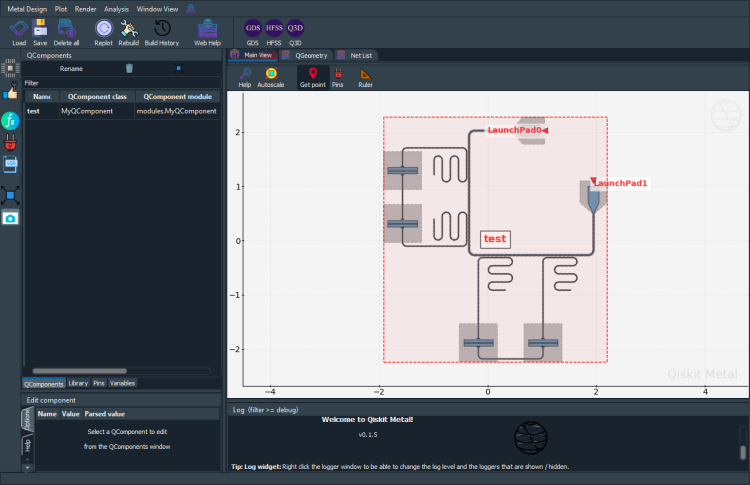

In [5]:
component = "test"
gui.rebuild()
#gui.autoscale()
#gui.edit_component(component)
gui.zoom_on_components([component])
gui.highlight_components([component])
gui.screenshot()

In [6]:
eig_qres = EPRanalysis(design, "hfss")
# example: update single setting
eig_qres.sim.setup.max_passes = 6
eig_qres.sim.setup.vars.Lj = '11 nH'
# example: update multiple settings
eig_qres.sim.setup_update(max_delta_f = 0.4, min_freq_ghz = 1.1)
eig_qres.sim.setup

{'name': 'Setup',
 'reuse_selected_design': True,
 'reuse_setup': True,
 'min_freq_ghz': 1.1,
 'n_modes': 1,
 'max_delta_f': 0.4,
 'max_passes': 6,
 'min_passes': 1,
 'min_converged': 1,
 'pct_refinement': 30,
 'basis_order': 1,
 'vars': {'Lj': '11 nH', 'Cj': '0 fF'}}

In [7]:
#eig_qres.sim.run(name="Qbit", components=['test'], open_terminations=[], box_plus_buffer = False)
#eig_qres.sim.plot_convergences()

In [8]:
#eig_qres.sim.plot_fields('main', eigenmode=1)

In [9]:
#eig_qres.sim.setup.n_modes = 10
#eig_qres.sim.run()

In [10]:
#eig_qres.sim.plot_fields('main', eigenmode=4)

## EPR Analysis

In [11]:
eig_qres.setup

{'junctions': {'jj': {'Lj_variable': 'Lj',
   'Cj_variable': 'Cj',
   'rect': '',
   'line': ''}},
 'dissipatives': {'dielectrics_bulk': ['main']},
 'cos_trunc': 8,
 'fock_trunc': 7,
 'sweep_variable': 'Lj'}

In [12]:
design.components
#design.qgeometry.get_component(name = "", table_name = 'junction')
#design.qgeometry.tables["junction"]

{1: name:    test
class:   MyQComponent          
options: 
  'pos_x'             : '0.0um',                      
  'pos_y'             : '0.0um',                      
  'orientation'       : '0.0',                        
  'chip'              : 'main',                       
  'layer'             : '1',                          
  'filename'          : 'chipdesign',                 
module:  modules.MyQComponent
id:      1
}

In [13]:
design.qgeometry.tables['junction']

,component,name,geometry,layer,subtract,helper,chip,width,hfss_inductance,hfss_capacitance,...,hfss_mesh_kw_jj,q3d_inductance,q3d_capacitance,q3d_resistance,q3d_mesh_kw_jj,gds_cell_name,aedt_q3d_inductance,aedt_q3d_capacitance,aedt_hfss_inductance,aedt_hfss_capacitance
0,1,Junction0,"LINESTRING (1.02000 -1.88900, 1.02000 -1.87300)",1,False,False,main,0.01,10nH,0,...,0.000007,10nH,0,0,0.000007,my_other_junction,1.000000e-08,0,1.000000e-08,0
1,1,Junction1,"LINESTRING (-0.17000 -1.88900, -0.17000 -1.87300)",1,False,False,main,0.01,10nH,0,...,0.000007,10nH,0,0,0.000007,my_other_junction,1.000000e-08,0,1.000000e-08,0
2,1,Junction2,"LINESTRING (-1.56500 0.32300, -1.56500 0.30700)",1,False,False,main,0.01,10nH,0,...,0.000007,10nH,0,0,0.000007,my_other_junction,1.000000e-08,0,1.000000e-08,0
3,1,Junction3,"LINESTRING (-1.56500 1.28200, -1.56500 1.29800)",1,False,False,main,0.01,10nH,0,...,0.000007,10nH,0,0,0.000007,my_other_junction,1.000000e-08,0,1.000000e-08,0


In [ ]:
for index in design.qgeometry.tables['junction'].index:
    design.qgeometry.tables['junction'].loc[index,"hfss_inductance"] = f"Lj{index}"
    design.qgeometry.tables['junction'].loc[index,"hfss_capacitance"] = f"Cj{index}"

design.qgeometry.tables['junction']

Junction0 {'end': [1020.0, -1873.0], 'start': [1020.0, -1889.0], 'width': 10.0}
Junction1 {'end': [-170.0, -1873.0], 'start': [-170.0, -1889.0], 'width': 10.0}
Junction2 {'end': [-1565.0000000000005, 307.0], 'start': [-1565.0000000000005, 323.0], 'width': 10.0}
Junction3 {'end': [-1565.0000000000005, 1298.0], 'start': [-1565.0000000000005, 1282.0], 'width': 10.0}


,component,name,geometry,layer,subtract,helper,chip,width,hfss_inductance,hfss_capacitance,...,hfss_mesh_kw_jj,q3d_inductance,q3d_capacitance,q3d_resistance,q3d_mesh_kw_jj,gds_cell_name,aedt_q3d_inductance,aedt_q3d_capacitance,aedt_hfss_inductance,aedt_hfss_capacitance
0,1,Junction0,"LINESTRING (1.02000 -1.88900, 1.02000 -1.87300)",1,False,False,main,0.01,10nH,0,...,0.000007,10nH,0,0,0.000007,my_other_junction,1.000000e-08,0,1.000000e-08,0
1,1,Junction1,"LINESTRING (-0.17000 -1.88900, -0.17000 -1.87300)",1,False,False,main,0.01,10nH,0,...,0.000007,10nH,0,0,0.000007,my_other_junction,1.000000e-08,0,1.000000e-08,0
2,1,Junction2,"LINESTRING (-1.56500 0.32300, -1.56500 0.30700)",1,False,False,main,0.01,10nH,0,...,0.000007,10nH,0,0,0.000007,my_other_junction,1.000000e-08,0,1.000000e-08,0
3,1,Junction3,"LINESTRING (-1.56500 1.28200, -1.56500 1.29800)",1,False,False,main,0.01,10nH,0,...,0.000007,10nH,0,0,0.000007,my_other_junction,1.000000e-08,0,1.000000e-08,0


In [15]:
eig_qres.setup

{'junctions': {'jj': {'Lj_variable': 'Lj',
   'Cj_variable': 'Cj',
   'rect': '',
   'line': ''}},
 'dissipatives': {'dielectrics_bulk': ['main']},
 'cos_trunc': 8,
 'fock_trunc': 7,
 'sweep_variable': 'Lj'}

In [16]:
del eig_qres.setup.junctions['jj']
#for jj in design.qgeometry.tables['junction']['name'].tolist():
for index in design.qgeometry.tables['junction'].index:
    name = design.qgeometry.tables['junction'].loc[index,"name"]
    Lj = design.qgeometry.tables['junction'].loc[index,"hfss_inductance"]
    Cj = design.qgeometry.tables['junction'].loc[index,"hfss_capacitance"]
    eig_qres.setup.junctions[name] = Dict(rect=f'JJ_rect_Lj_{name}_rect_jj', line=f'JJ_Lj_{name}_rect_jj',
                  Lj_variable=Lj, Cj_variable=Cj)
    print(name, name, Lj, Cj)

Junction0 Junction0 10nH 0
Junction1 Junction1 10nH 0
Junction2 Junction2 10nH 0
Junction3 Junction3 10nH 0


In [17]:
eig_qres.setup.sweep_variable = 'Lj1'
eig_qres.setup

{'junctions': {'Junction0': {'rect': 'JJ_rect_Lj_Junction0_rect_jj',
   'line': 'JJ_Lj_Junction0_rect_jj',
   'Lj_variable': '10nH',
   'Cj_variable': 0},
  'Junction1': {'rect': 'JJ_rect_Lj_Junction1_rect_jj',
   'line': 'JJ_Lj_Junction1_rect_jj',
   'Lj_variable': '10nH',
   'Cj_variable': 0},
  'Junction2': {'rect': 'JJ_rect_Lj_Junction2_rect_jj',
   'line': 'JJ_Lj_Junction2_rect_jj',
   'Lj_variable': '10nH',
   'Cj_variable': 0},
  'Junction3': {'rect': 'JJ_rect_Lj_Junction3_rect_jj',
   'line': 'JJ_Lj_Junction3_rect_jj',
   'Lj_variable': '10nH',
   'Cj_variable': 0}},
 'dissipatives': {'dielectrics_bulk': ['main']},
 'cos_trunc': 8,
 'fock_trunc': 7,
 'sweep_variable': 'Lj1'}

In [19]:
eig_qres.sim.setup.vars = Dict(
    Lj0 = '11 nH', 
    Cj0 = '0 fF',
    Lj1 = '9 nH', 
    Cj1 = '0 fF',
    Lj2 = '13 nH', 
    Cj2 = '0 fF',
    Lj3 = '10 nH', 
    Cj3 = '0 fF',    
)

In [20]:
eig_qres.sim.renderer.options['x_buffer_width_mm'] = 0.5
eig_qres.sim.renderer.options['y_buffer_width_mm'] = 0.5
eig_qres.sim.renderer.options

{'Lj': '10nH',
 'Cj': 0,
 '_Rj': 0,
 'max_mesh_length_jj': '7um',
 'max_mesh_length_port': '7um',
 'project_path': None,
 'project_name': None,
 'design_name': None,
 'x_buffer_width_mm': 0.5,
 'y_buffer_width_mm': 0.5,
 'wb_threshold': '400um',
 'wb_offset': '0um',
 'wb_size': 5,
 'plot_ansys_fields_options': {'name': 'NAME:Mag_E1',
  'UserSpecifyName': '0',
  'UserSpecifyFolder': '0',
  'QuantityName': 'Mag_E',
  'PlotFolder': 'E Field',
  'StreamlinePlot': 'False',
  'AdjacentSidePlot': 'False',
  'FullModelPlot': 'False',
  'IntrinsicVar': "Phase='0deg'",
  'PlotGeomInfo_0': '1',
  'PlotGeomInfo_1': 'Surface',
  'PlotGeomInfo_2': 'FacesList',
  'PlotGeomInfo_3': '1'}}

In [21]:
eig_qres.sim.run(name="Qbit", components=['test'], open_terminations=[], box_plus_buffer = False)

INFO 12:49AM [connect_project]: Connecting to Ansys Desktop API...
INFO 12:49AM [load_ansys_project]: 	Opened Ansys App
INFO 12:49AM [load_ansys_project]: 	Opened Ansys Desktop v2023.2.0
INFO 12:49AM [load_ansys_project]: 	Opened Ansys Project
	Folder:    C:/HFSS/ymino/
	Project:   Project12
INFO 12:49AM [connect_design]: No active design found (or error getting active design).
INFO 12:49AM [connect]: 	 Connected to project "Project12". No design detected
INFO 12:49AM [connect_design]: 	Opened active design
	Design:    Qbit_hfss [Solution type: Eigenmode]
WARNING 12:49AM [connect_setup]: 	No design setup detected.
WARNING 12:49AM [connect_setup]: 	Creating eigenmode default setup.
INFO 12:49AM [get_setup]: 	Opened setup `Setup`  (<class 'pyEPR.ansys.HfssEMSetup'>)
INFO 12:54AM [get_setup]: 	Opened setup `Setup`  (<class 'pyEPR.ansys.HfssEMSetup'>)
INFO 12:54AM [analyze]: Analyzing setup Setup
01:18AM 16s INFO [get_f_convergence]: Saved convergences to c:\Users\ymino\Documents\GitHub\qi

In [ ]:
design_name= "Sweep_DrivenModal"
qcomp_render = [] # Means to render everything in qgeometry table.
open_terminations = []

# Here, pin LP1_in and LP2_in are converted into lumped ports,
#           each with an impedance of 50 Ohms. <br>
port_list = [('test', 'LaunchPad0', 50),
             ('test', 'LaunchPad1', 50)]
#port_list = []
box_plus_buffer = True

In [ ]:
# we use HFSS as rendere
hfss = em1.renderer
hfss.start()

INFO 04:51PM [connect_project]: Connecting to Ansys Desktop API...
INFO 04:51PM [load_ansys_project]: 	Opened Ansys App
INFO 04:51PM [load_ansys_project]: 	Opened Ansys Desktop v2023.2.0
INFO 04:51PM [load_ansys_project]: 	Opened Ansys Project
	Folder:    C:/HFSS/ymino/
	Project:   Project8
INFO 04:51PM [connect_design]: 	Opened active design
	Design:    HangingResonator [Solution type: HFSS Hybrid Modal Network]
INFO 04:51PM [get_setup]: 	Opened setup `Setup`  (<class 'pyEPR.ansys.HfssDMSetup'>)
INFO 04:51PM [connect]: 	Connected to project "Project8" and design "HangingResonator" 😀 



True

In [ ]:
# Here we activate the design for a drivenmodal solution
hfss.activate_ansys_design("HangingResonator", 'hfss hybrid modal network')
setup_args = Dict(max_delta_s=0.001)
setup_args.name = 'Setup'
hfss.edit_drivenmodal_setup(setup_args)

INFO 04:51PM [connect_design]: 	Opened active design
	Design:    HangingResonator [Solution type: HFSS Hybrid Modal Network]
04:51PM 22s WARNING [edit_drivenmodal_setup]: The design does not have solution type as "Driven Modal". The Setup not updated.


In [ ]:
# set buffer
hfss.options['x_buffer_width_mm'] = 0.1
hfss.options['y_buffer_width_mm'] = 0.1

In [ ]:
# clean the design if needed
hfss.clean_active_design()

In [ ]:
# render the design
hfss.render_design(selection=[], 
                   open_pins=open_terminations, 
                   port_list=port_list, 
                   box_plus_buffer = box_plus_buffer)

In [ ]:
pinfo = hfss.pinfo
pinfo.design.set_variable('Lj', '10 nH')
pinfo.design.set_variable('Cj', '0 fF')

'Cj'

In [ ]:
hfss.add_sweep(setup_name="Setup", 
               name="Sweep", 
               start_ghz=7.0,
               stop_ghz=10.0,
               count=601,
               type="Interpolating")

INFO 03:08PM [get_setup]: 	Opened setup `Setup`  (<class 'pyEPR.ansys.HfssDMSetup'>)


In [ ]:
hfss.analyze_sweep('Sweep', 'Setup')

INFO 03:08PM [get_setup]: 	Opened setup `Setup`  (<class 'pyEPR.ansys.HfssDMSetup'>)
INFO 03:08PM [analyze]: Analyzing setup Setup : Sweep


03:28PM 54s CRITICAL [_qt_message_handler]: line: 0, func: None(), file: None  CRITICAL: QEventDispatcherWin32::wakeUp: Failed to post a message (Not enough quota is available to process this command.)



(                       S11                 S21
 7.000  -0.095928-0.002572j  0.027194+0.995013j
 7.005  -0.095997-0.002479j  0.028350+0.994975j
 7.010  -0.096066-0.002387j  0.029507+0.994935j
 7.015  -0.096135-0.002296j  0.030664+0.994893j
 7.020  -0.096204-0.002205j  0.031822+0.994850j
 ...                    ...                 ...
 9.980  -0.097163+0.073743j  0.646332+0.753244j
 9.985  -0.097102+0.073875j  0.647203+0.752491j
 9.990  -0.097041+0.074007j  0.648072+0.751737j
 9.995  -0.096979+0.074138j  0.648941+0.750982j
 10.000 -0.096917+0.074270j  0.649809+0.750226j
 
 [601 rows x 2 columns],
 <Figure size 1000x600 with 2 Axes>)

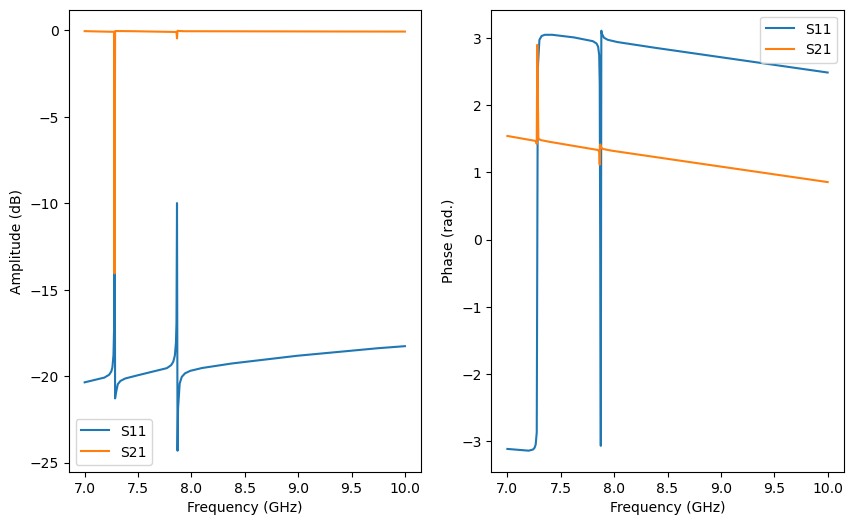

In [ ]:
%matplotlib inline
hfss.plot_params(['S11', 'S21'])

In [ ]:
hfss.disconnect_ansys()